# 도넛 행성 (BFS)
## 문제
[출처](https://www.acmicpc.net/problem/27211)
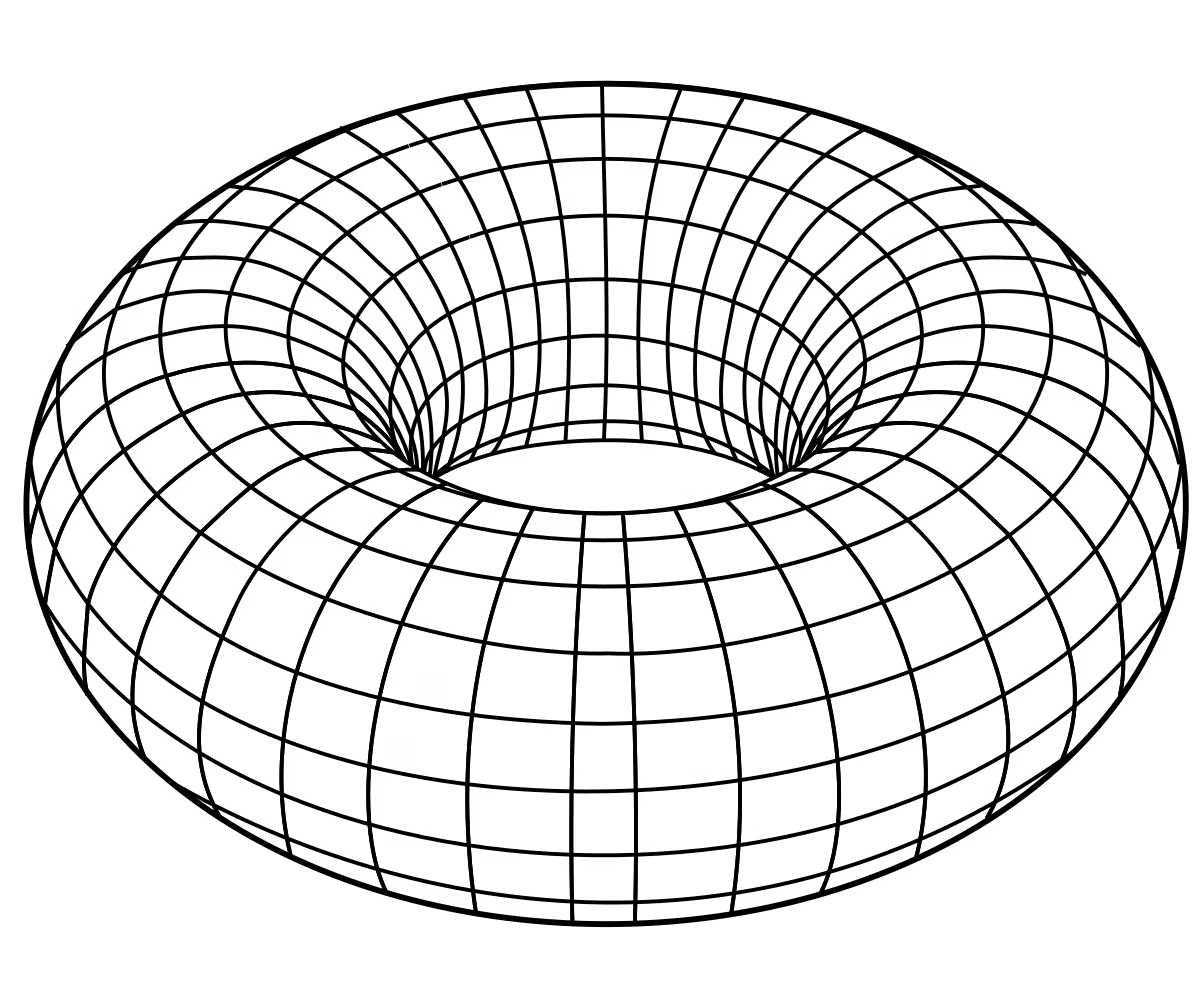
준겸이는 
$N \times M$칸으로 이루어진 도넛 모양의 행성에 살고 있다. 준겸이가 살고 있는 행성에는 위 그림처럼 격자 모양으로 줄이 그어져 있다. 행성의 각 칸은 숲으로 막혀 있거나, 지나갈 수 있도록 비어 있다.

준겸이는 본인의 집이 있는 위치를 기준으로 삼아 
$(0,0)$이라고 표시하기로 했다. 준겸이는 행성 위에서 상하좌우로 걸어 다닐 수 있다. 준겸이가 오른쪽으로 한 칸 걸어가면, 위치 
$(0,1)$에 도달할 것이다. 마찬가지로 아래로 한 칸 걸어가면, 위치 
$(1,0)$에 도달할 것이다. 준겸이가 
$(0,0)$에서 
$M$칸 오른쪽으로 걸어가면, 한 바퀴를 돌아 다시 원래 자리로 되돌아오게 된다. 비슷하게 
$(0,0)$에서 
$N$칸 아래로 걸어가면, 
$(0,0)$으로 돌아오게 된다. 행성은 연결되어 있기 때문에, 준겸이가 
$(0,0)$에서 왼쪽으로 한 칸 걸어가면 위치 
$(0,M-1)$에 도달할 것이다. 마찬가지로 준겸이가 
$(0,0)$에서 위로 한 칸 걸어가면 
$(N-1, 0)$에 도달하게 된다.

준겸이는 행성을 탐험하려고 한다. 만약 준겸이가 비어 있는 어떤 칸 
$A=(p_1,q_1)$에서 시작해, 숲에 막히지 않고 비어 있는 칸 
$B=(p_2,q_2)$에 도달할 수 있다면 
$A$와 
$B$는 같은 구역이다. 반대로, 도달할 수 없다면 
$A$와 
$B$는 서로 다른 구역이다. 당신은 준겸이가 탐험할 수 있는 빈 구역의 개수가 몇 개인지 출력해야 한다.

## 입력
첫 번째 줄에 
$N$과 
$M$이 공백을 사이에 두고 주어진다.

두 번째 줄부터 
$N$개의 줄에 걸쳐 
$N \times M$개의 칸에 대한 정보가 주어진다. 두 번째 줄에서부터 
$i$번째 줄에 주어지는 
$j$번째 정수는 칸 
$(i-1, j-1)$에 대한 정보이다. 만약 0이라면 비어 있는 것이고, 1이라면 숲으로 막혀 있는 것이다.

## 출력
탐험할 수 있는 구역의 개수를 출력한다.

## 제한
* $2 \le N \le 1\,000$ 
* $2 \le M \le 1\,000$ 

## 예제 입력 1 
```
5 6
1 1 1 1 1 1
1 0 0 0 1 1
1 1 1 1 0 0
1 1 1 1 0 0
1 1 1 1 1 1
```

## 예제 출력 1
2

In [ ]:
# 답안 출처: https://webdiv-diary.tistory.com/9
import sys
from collections import deque
### 아래부터 백준 제출 시 없애야 하는 부분
import io
input_data = """5 6
1 1 1 1 1 1
1 0 0 0 1 1
1 1 1 1 0 0
1 1 1 1 0 0
1 1 1 1 1 1
"""
sys.stdin = io.StringIO(input_data)
### 여기까지 제거

input = sys.stdin.readline

dx = [0,0,-1,1]
dy = [-1,1,0,0]

def bfs(x, y):
    queue = deque()
    queue.append((x, y))
    visited[x][y] = 1

    while queue:
        a, b = queue.popleft()
        for i in range(4):
            nx =  a + dx[i]
            ny =  b + dy[i]

            if nx >= N:
                nx = 0
            elif nx <= -1:
                nx = N-1

            if ny >= M:
                ny = 0
            elif ny <= -1:
                ny = M-1

            if graph[nx][ny] == 0 and visited[nx][ny] == 0:
                visited[nx][ny] = 1
                queue.append((nx, ny))


N, M = map(int, input().split())
graph = []
for i in range(N):
    graph.append(list(map(int, input().split())))

visited = [[0] * M for _ in range(N)]
cnt = 0
for i in range(N):
    for j in range(M):
        if visited[i][j] == 0 and graph[i][j] == 0:
            bfs(i, j)
            cnt += 1

print(cnt)

2


In [5]:
# 내가 작성한 답안 초안: 오답 출력. 7이라고 나옴.
import sys
### 아래부터 백준 제출 시 없애야 하는 부분
import io
input_data = """5 6
1 1 1 1 1 1
1 0 0 0 1 1
1 1 1 1 0 0
1 1 1 1 0 0
1 1 1 1 1 1
"""
sys.stdin = io.StringIO(input_data)
### 여기까지 제거 
input = sys.stdin.readline

# bfs 함수 정의 
from collections import deque
nx = [-1, 1, 0, 0]
ny = [0, 0, -1, 1]

def bfs(x, y):
    queue = deque()
    queue.append((x, y))
    visited[x][y] = 1

    # queue 가 유효한 동안 방문 처리 
    while queue: 
        a, b = queue.popleft()

        # 상하좌우 체크 
        for i in range(len(nx)):
            tx = a + nx[i]
            ty = b + ny[i]

            # 도넛형 행성이기에 새로운 좌표를 조건에 맞게 바꾸기 
            if tx >= n:
                tx = 0 
            elif tx < 0:
                tx = n - 1
            
            if ty >= m:
                ty = 0 
            elif ty < 0:
                ty = m - 1
            
            # 새로운 좌표에 숲이 있다면 나가기 & 방문 안 한 노드는 방문 처리
            if graph[tx][ty] == 0 and not visited[tx][ty]:
                visited[tx][ty] = True
                queue.append((tx, ty))

# N x M 칸수 읽기
n, m = map(int, input().split())

# 행성 지도 읽기: 0이 갈 수 있는 영역, 1은 갈 수 없는 영역 
graph = []

for _ in range(n):
    graph.append(list(map(int, input().split())))

visited = [[False] * m for _ in range(n)]

# 지도 모든 영역에서 bfs 실시 
result = 0 

for i in range(n):
    for j in range(m):
        if visited[i][j] == 0 and graph[i][j] == 0:
            bfs(i, j)
            result += 1 
print(result)

2
